In [1]:
import ctypes
import numpy as np
import pandas as pd
import os
import plotly as plt 
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display
from pathlib import Path
from torchvision import transforms
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

In [2]:
# === Charger la DLL Rust ===
lib = ctypes.CDLL("target/release/mymodel.dll")

In [3]:
# === Paramètres ===
IMAGE_SIZE = (64, 64)
SUPPORTED_EXTENSIONS = {".png", ".jpg", ".jpeg"}
FILTER_LABELS = ["A", "B", "C"]  

# === Transformer torchvision ===
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.Grayscale(),
    transforms.ToTensor()
])

# === Chargement des images ===
def load_images_from_directory(root_dir, filter_labels=None):
    images, labels = [], []
    root_dir = Path(root_dir)

    for label_dir in sorted(root_dir.iterdir()):
        if not label_dir.is_dir():
            continue
        label = label_dir.name
        if filter_labels and label not in filter_labels:
            continue

        for img_path in label_dir.glob("*"):
            if img_path.suffix.lower() not in SUPPORTED_EXTENSIONS:
                continue
            try:
                img = Image.open(img_path).convert("RGB")
                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f"Erreur {img_path}: {e}")
    
    return images, labels



In [4]:
# === Prétraitement pour softmax (X: float64, y: int64) ===
def preprocess_for_softmax(images, labels):
    X = np.stack([transform(img).numpy().flatten() for img in images])
    X = X.astype(np.float64)

    le = LabelEncoder()
    y_int = le.fit_transform(labels).astype(np.uint64)

    print("Classes reconnues :", le.classes_)
    print("Labels encodés :", y_int)

    return X, y_int, le

In [5]:
# === Définir les signatures ===
lib.create_softmax_model.argtypes = [
    ctypes.c_size_t, ctypes.c_size_t, ctypes.c_double, ctypes.c_size_t, ctypes.c_double
]
lib.create_softmax_model.restype = ctypes.c_void_p

lib.train_softmax_model.argtypes = [
    ctypes.c_void_p,
    ctypes.POINTER(ctypes.c_double),
    ctypes.POINTER(ctypes.c_uint64),
    ctypes.c_size_t,
    ctypes.c_size_t
]
lib.train_softmax_model.restype = None

lib.predict_softmax_model.argtypes = [
    ctypes.c_void_p,
    ctypes.POINTER(ctypes.c_double),
    ctypes.c_size_t
]
lib.predict_softmax_model.restype = ctypes.c_size_t

In [ ]:
# === Charger et préparer les données ===
train_images, train_labels = load_images_from_directory("dataset/train", FILTER_LABELS)
test_images, test_labels = load_images_from_directory("dataset/test", FILTER_LABELS)

X_train, y_train, label_encoder = preprocess_for_softmax(train_images, train_labels)
X_test, y_test, _ = preprocess_for_softmax(test_images, test_labels)

n_samples, n_features = X_train.shape
n_classes = len(np.unique(y_train))




Classes reconnues : ['A' 'B' 'C']
Labels encodés : [0 0 0 ... 2 2 2]
Classes reconnues : ['A' 'B' 'C']
Labels encodés : [0 1 2]


In [7]:
# === Création du modèle ===
learning_rate = 0.01
epochs = 3000
lambda_reg = 0.01

model_ptr = lib.create_softmax_model(n_features, n_classes, learning_rate, epochs, lambda_reg)

# === Entraînement ===
x_ptr = X_train.astype(np.float64).flatten().ctypes.data_as(ctypes.POINTER(ctypes.c_double))
y_ptr = y_train.ctypes.data_as(ctypes.POINTER(ctypes.c_uint64))

lib.train_softmax_model(model_ptr, x_ptr, y_ptr, n_samples, n_features)


In [ ]:
# === Prédiction sur X_test ===
y_pred = []
for x in X_test:
    x_ptr = x.astype(np.float64).ctypes.data_as(ctypes.POINTER(ctypes.c_double))
    pred = lib.predict_softmax_model(model_ptr, x_ptr, n_features)
    y_pred.append(pred)

y_pred = np.array(y_pred)

# === Évaluation ===
acc = accuracy_score(y_test, y_pred)
print(f" Accuracy test : {acc * 100:.2f}%")



 Accuracy test : 33.33%


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

clf = LogisticRegression(max_iter=3000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("Baseline sklearn logistic regression:", accuracy_score(y_test, y_pred))


Baseline sklearn logistic regression: 0.3333333333333333


Nombre d'images : 35
Taille de y_test : 3
Taille de y_pred : 3
Image nothing_test.jpg — Prédit : B | Réel : A


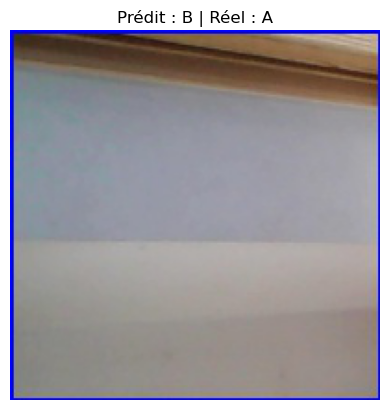

Image space_test.jpg — Prédit : B | Réel : B


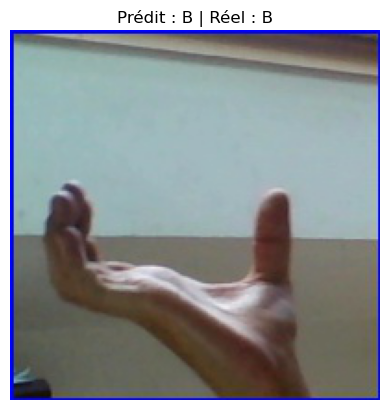

Image 1_001.jpg — Prédit : A | Réel : C


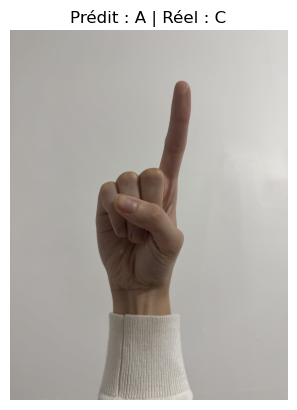

In [14]:

# === Générer les chemins des images test ===
test_image_paths = []
for root, _, files in os.walk("dataset/test"):
    for file in sorted(files):  # tri pour garder un ordre constant
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            test_image_paths.append(os.path.join(root, file))

# === Liste des étiquettes (label → classe) ===
label_map = [chr(ord('A') + i) for i in range(26)] + [str(i) for i in range(10)]
# A → 0, B → 1, ..., Z → 25, 0 → 26, ..., 9 → 35

# === Affichage image + prédiction ===
print(f"Nombre d'images : {len(test_image_paths)}")
print(f"Taille de y_test : {len(y_test)}")
print(f"Taille de y_pred : {len(y_pred)}")

for i, path in enumerate(test_image_paths):
    if i >= len(y_pred):
        break

    img = Image.open(path)

    pred_label = label_map[y_pred[i]]
    true_label = label_map[y_test[i]]

    print(f"Image {os.path.basename(path)} — Prédit : {pred_label} | Réel : {true_label}")
    plt.imshow(img)
    plt.title(f"Prédit : {pred_label} | Réel : {true_label}")
    plt.axis("off")
    plt.show()
